In [2]:
import pandas as pd

# Create a list of your exact dataset names
dataset_names = [
    "Industrial_and_Scientific",
    "Video_Games",
    "Cell_Phones_and_Accessories"
]

# Loop through each dataset and process it
for name in dataset_names:
    print(f"--- Starting: {name} ---")
    
    # 1. Load the pre-split CSVs (Pandas auto-unzips .gz)
    train_df = pd.read_csv(f'../data/{name}.train.csv.gz')
    valid_df = pd.read_csv(f'../data/{name}.valid.csv.gz')
    test_df = pd.read_csv(f'../data/{name}.test.csv.gz')
    
    # 2. Load the metadata (The Text)
    meta_df = pd.read_json(f'../data/meta_{name}.jsonl.gz', lines=True, compression='gzip')
    meta_df = meta_df[['parent_asin', 'title', 'description']]
    
    # Clean the text (convert lists to strings)
    meta_df['description'] = meta_df['description'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
    
    # 3. Merge the text onto your splits
    train_merged = pd.merge(train_df, meta_df, on='parent_asin', how='inner')
    valid_merged = pd.merge(valid_df, meta_df, on='parent_asin', how='inner')
    test_merged = pd.merge(test_df, meta_df, on='parent_asin', how='inner')
    
    print(f"Merged successfully! Train: {len(train_merged)} | Valid: {len(valid_merged)} | Test: {len(test_merged)}")
    
    # 4. Save the new text-enriched splits
    # Making the names lowercase just to keep the output files tidy
    clean_name = name.lower()
    train_merged.to_csv(f'../data/train_{clean_name}_merged.csv', index=False)
    valid_merged.to_csv(f'../data/valid_{clean_name}_merged.csv', index=False)
    test_merged.to_csv(f'../data/test_{clean_name}_merged.csv', index=False)
    
    print(f"Saved to data folder!\n")

print("All datasets processed and ready for modeling!")

--- Starting: Industrial_and_Scientific ---
Merged successfully! Train: 310977 | Valid: 50985 | Test: 50985
Saved to data folder!

--- Starting: Video_Games ---
Merged successfully! Train: 625062 | Valid: 94762 | Test: 94762
Saved to data folder!

--- Starting: Cell_Phones_and_Accessories ---
Merged successfully! Train: 1990787 | Valid: 380999 | Test: 380999
Saved to data folder!

All datasets processed and ready for modeling!


Loading data for EDA...


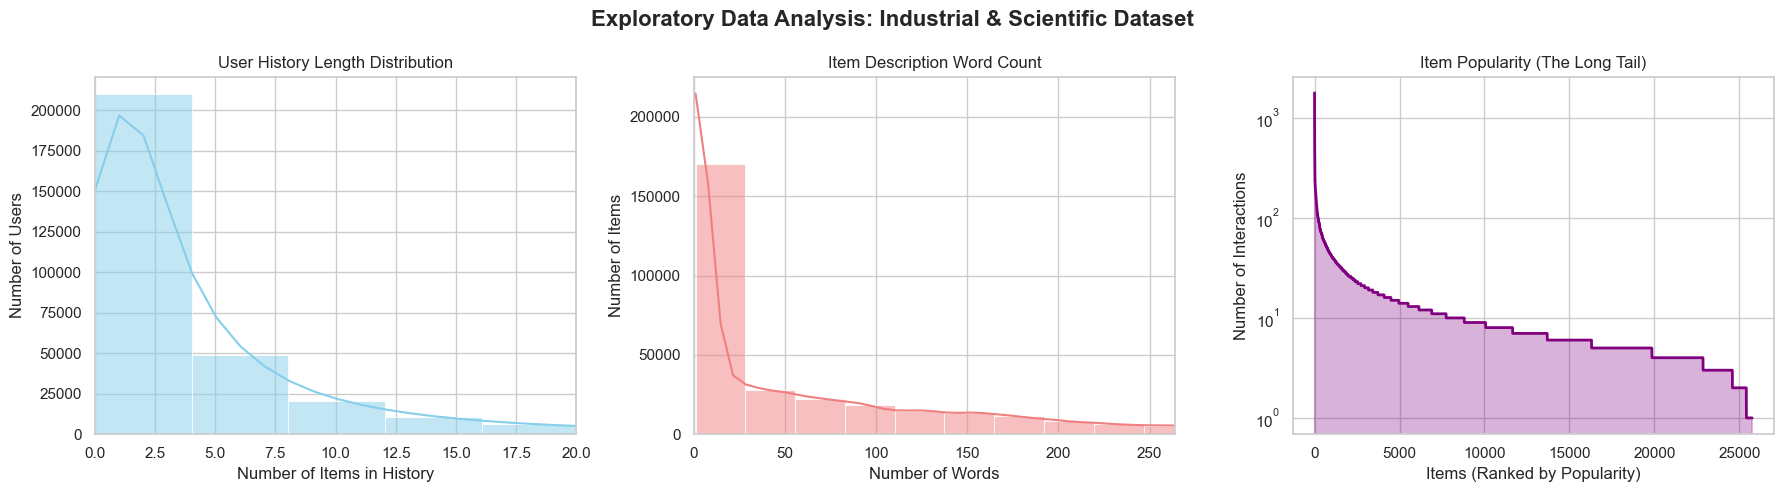


--- Key Parameters for Model Configuration ---
95% of users have a history length of 20 items or fewer.
95% of item descriptions are 264 words or fewer.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for your capstone report charts
sns.set_theme(style="whitegrid", palette="muted")

print("Loading data for EDA...")
# Load the merged training data for Industrial & Scientific
df = pd.read_csv('../data/train_industrial_and_scientific_merged.csv')

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis: Industrial & Scientific Dataset', fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# CHART 1: History Sequence Length
# Calculate how many past items each user interacted with
# ---------------------------------------------------------
# The history column contains space-separated IDs. We split them and count the length.
df['history_length'] = df['history'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

sns.histplot(df['history_length'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('User History Length Distribution')
axes[0].set_xlabel('Number of Items in History')
axes[0].set_ylabel('Number of Users')
axes[0].set_xlim(0, df['history_length'].quantile(0.95)) # Zoom in on the 95th percentile to hide extreme outliers

# ---------------------------------------------------------
# CHART 2: Text Word Count (For LLM Token Limits)
# Calculate the length of the product descriptions
# ---------------------------------------------------------
df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

sns.histplot(df['desc_word_count'], bins=50, ax=axes[1], color='lightcoral', kde=True)
axes[1].set_title('Item Description Word Count')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Number of Items')
axes[1].set_xlim(0, df['desc_word_count'].quantile(0.95))

# ---------------------------------------------------------
# CHART 3: The Long-Tail Popularity Bias
# Show how a few items get all the clicks, while most get very few
# ---------------------------------------------------------
item_counts = df['parent_asin'].value_counts().values

axes[2].plot(item_counts, color='purple', linewidth=2)
axes[2].fill_between(range(len(item_counts)), item_counts, color='purple', alpha=0.3)
axes[2].set_title('Item Popularity (The Long Tail)')
axes[2].set_xlabel('Items (Ranked by Popularity)')
axes[2].set_ylabel('Number of Interactions')
# Use a log scale so the massive drop-off is visually clear
axes[2].set_yscale('log') 

# Adjust layout so labels don't overlap and display the charts
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print Exact Mathematical Parameters for your Models
# ---------------------------------------------------------
print("\n--- Key Parameters for Model Configuration ---")
print(f"95% of users have a history length of {int(df['history_length'].quantile(0.95))} items or fewer.")
print(f"95% of item descriptions are {int(df['desc_word_count'].quantile(0.95))} words or fewer.")

In [6]:
import pandas as pd

# These match the exact names in your screenshot!
dataset_names = [
    "industrial_and_scientific",
    "video_games",
    "cell_phones_and_accessories"
]

print("--- Key Parameters for Model Configuration ---")

for name in dataset_names:
    print(f"\nLoading {name}...")
    # Load the merged training data using your exact file structure
    df = pd.read_csv(f'../data/train_{name}_merged.csv')
    
    # Calculate lengths (handling any potential missing text gracefully)
    df['history_length'] = df['history'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
    df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
    
    # Print the 95th percentile
    print(f"Dataset: {name.upper()}")
    print(f" -> 95% of users have a history length of {int(df['history_length'].quantile(0.95))} items or fewer.")
    print(f" -> 95% of item descriptions are {int(df['desc_word_count'].quantile(0.95))} words or fewer.")

--- Key Parameters for Model Configuration ---

Loading industrial_and_scientific...
Dataset: INDUSTRIAL_AND_SCIENTIFIC
 -> 95% of users have a history length of 20 items or fewer.
 -> 95% of item descriptions are 264 words or fewer.

Loading video_games...
Dataset: VIDEO_GAMES
 -> 95% of users have a history length of 28 items or fewer.
 -> 95% of item descriptions are 1063 words or fewer.

Loading cell_phones_and_accessories...
Dataset: CELL_PHONES_AND_ACCESSORIES
 -> 95% of users have a history length of 12 items or fewer.
 -> 95% of item descriptions are 253 words or fewer.



Generating EDA Charts for: VIDEO_GAMES


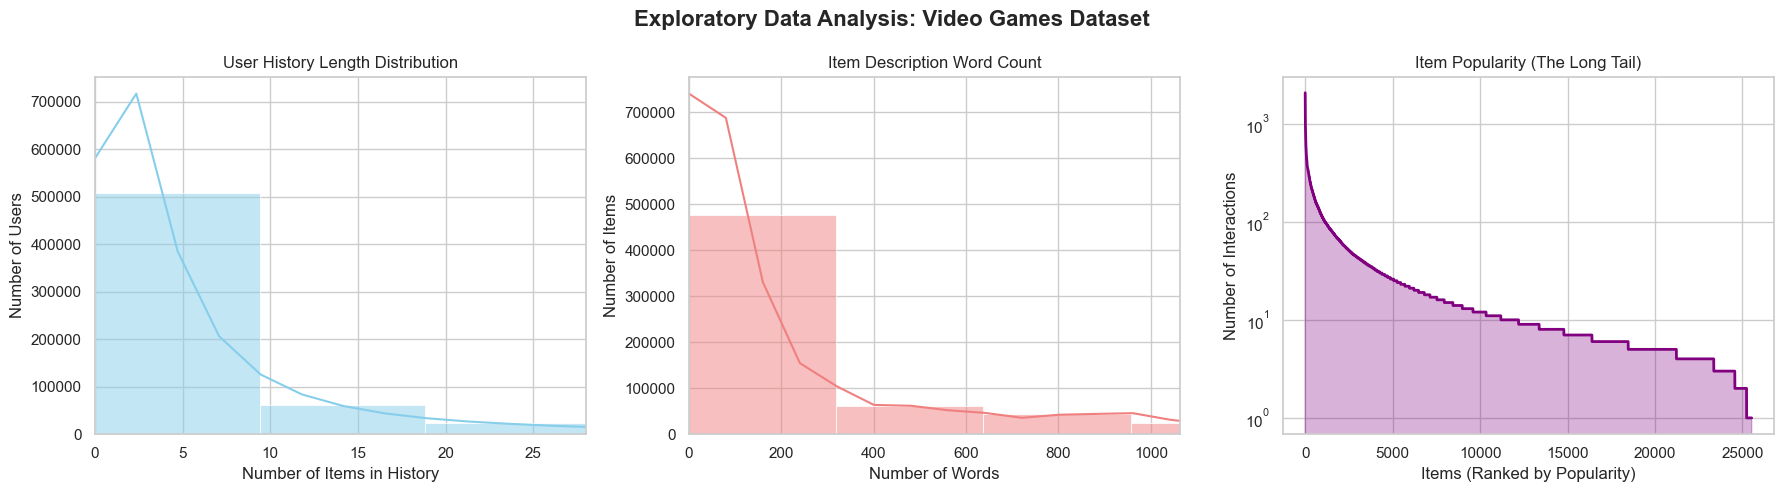


Generating EDA Charts for: CELL_PHONES_AND_ACCESSORIES


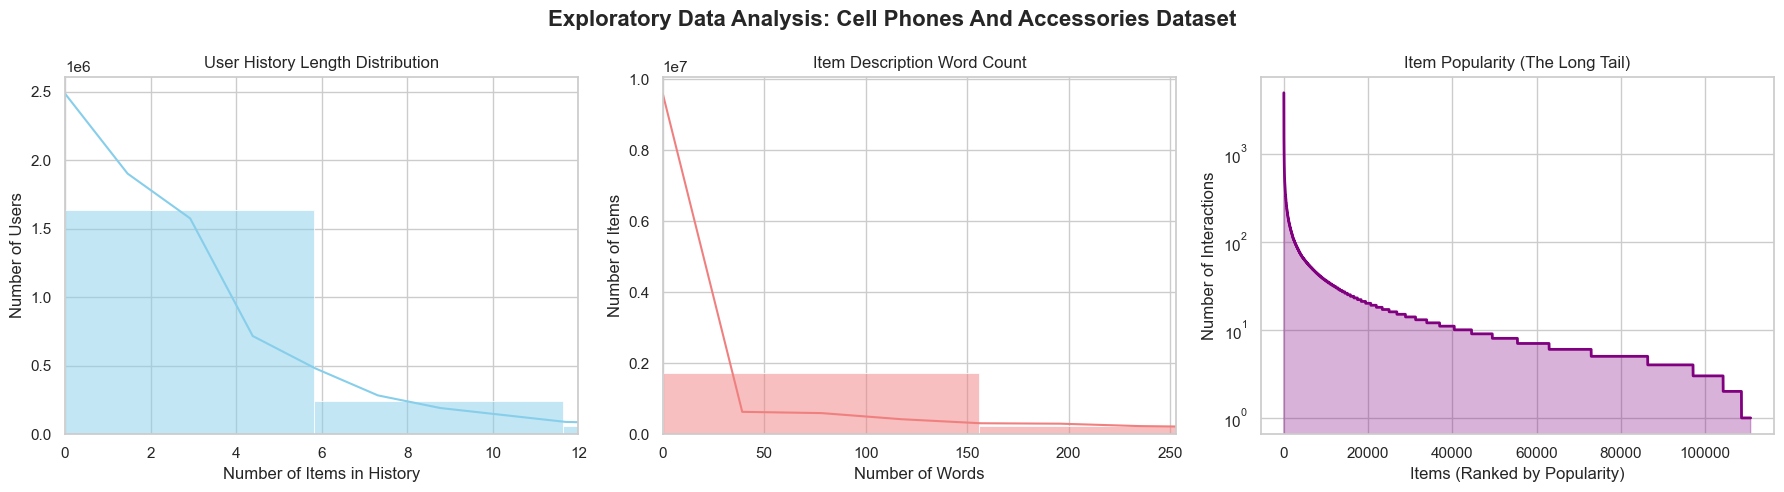

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for your capstone report charts
sns.set_theme(style="whitegrid", palette="muted")

# We already did Industrial, so let's just do the other two
dataset_names = [
    "video_games",
    "cell_phones_and_accessories"
]

for name in dataset_names:
    print(f"\n{'='*50}")
    print(f"Generating EDA Charts for: {name.upper()}")
    print(f"{'='*50}")
    
    # Load the merged training data
    df = pd.read_csv(f'../data/train_{name}_merged.csv')
    
    # Calculate lengths (handling any potential missing text gracefully)
    df['history_length'] = df['history'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
    df['desc_word_count'] = df['description'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
    
    # Create a figure with 3 subplots side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Clean up the name for the title (e.g., "video_games" -> "Video Games")
    title_name = name.replace("_", " ").title()
    fig.suptitle(f'Exploratory Data Analysis: {title_name} Dataset', fontsize=16, fontweight='bold')

    # ---------------------------------------------------------
    # CHART 1: History Sequence Length
    # ---------------------------------------------------------
    sns.histplot(df['history_length'], bins=50, ax=axes[0], color='skyblue', kde=True)
    axes[0].set_title('User History Length Distribution')
    axes[0].set_xlabel('Number of Items in History')
    axes[0].set_ylabel('Number of Users')
    
    # Zoom in on the 95th percentile to hide extreme outliers
    max_hist = df['history_length'].quantile(0.95)
    if max_hist > 0:
        axes[0].set_xlim(0, max_hist)

    # ---------------------------------------------------------
    # CHART 2: Text Word Count
    # ---------------------------------------------------------
    sns.histplot(df['desc_word_count'], bins=50, ax=axes[1], color='lightcoral', kde=True)
    axes[1].set_title('Item Description Word Count')
    axes[1].set_xlabel('Number of Words')
    axes[1].set_ylabel('Number of Items')
    
    max_desc = df['desc_word_count'].quantile(0.95)
    if max_desc > 0:
        axes[1].set_xlim(0, max_desc)

    # ---------------------------------------------------------
    # CHART 3: The Long-Tail Popularity Bias
    # ---------------------------------------------------------
    item_counts = df['parent_asin'].value_counts().values
    
    axes[2].plot(item_counts, color='purple', linewidth=2)
    axes[2].fill_between(range(len(item_counts)), item_counts, color='purple', alpha=0.3)
    axes[2].set_title('Item Popularity (The Long Tail)')
    axes[2].set_xlabel('Items (Ranked by Popularity)')
    axes[2].set_ylabel('Number of Interactions')
    axes[2].set_yscale('log') # Use a log scale so the drop-off is visually clear

    # Adjust layout so labels don't overlap and display the charts
    plt.tight_layout()
    plt.show()

In [8]:
import pandas as pd

print("Opening the Industrial & Scientific dataset...\n")

# Load your perfectly merged CSV file
file_path = '../data/train_industrial_and_scientific_merged.csv'
df = pd.read_csv(file_path)

# Let's randomly sample 3 users to see exactly what the data looks like
# We use random_state so it picks the same 3 users every time you run it
sample_users = df.sample(n=3, random_state=42)

for index, row in sample_users.iterrows():
    print("=" * 60)
    print(f"👤 USER ID: {row['user_id']}")
    print("-" * 60)
    print(f"🛒 PAST HISTORY (The IDs they clicked before):")
    print(f"   {row['history']}")
    print(f"\n🎯 TARGET ITEM (What they clicked next):")
    print(f"   ID:    {row['parent_asin']}")
    print(f"   Title: {row['title']}")
    
    # We will truncate the description so it doesn't flood your screen
    desc = str(row['description'])
    short_desc = desc[:150] + "..." if len(desc) > 150 else desc
    print(f"   Desc:  {short_desc}")
    print("=" * 60 + "\n")

Opening the Industrial & Scientific dataset...

👤 USER ID: AEQNKVI7A3PH2F3JQ3YPBAXFNIQA
------------------------------------------------------------
🛒 PAST HISTORY (The IDs they clicked before):
   nan

🎯 TARGET ITEM (What they clicked next):
   ID:    B004FBQAW2
   Title: Silica Gel Desiccants Packets - 1" X 2 3/8" - 3 Gram Packs - 10 Packets of Silica Gel 3Gr-Cotton-10pk - Dry-Packs Brand!
   Desc:  Silica Gel Packets will absorb up to 40% of it's weight in moisture and will work until it's fully absorbed. By placing with your valuables it will as...

👤 USER ID: AEDLXFNPPHTGP5WDDFWCGQPSV4NQ
------------------------------------------------------------
🛒 PAST HISTORY (The IDs they clicked before):
   B0BN7DPBG9 B01JOVO1N2 B01FFCVGBE B0BFQJL395 B07RPD7N87

🎯 TARGET ITEM (What they clicked next):
   ID:    B0C1ZZRS3L
   Title: Gorilla Super Glue Gel XL, 25 Gram, Clear, (Pack of 1)
   Desc:  Gorilla Super Glue Gel is an easy-to-use, thicker and more controlled formula* great for multiple 

In [11]:
import pandas as pd

# Point this to your merged dataset
file_path = '../data/train_industrial_and_scientific_merged.csv'

# Load the file
df = pd.read_csv(file_path)

# Grab exactly ONE row (the very first row at index 0)
row = df.iloc[0]
print(row)


user_id                             AFNT6ZJCYQN3WDIKUSWHJDXNND2Q
parent_asin                                           B00DX7KEP8
rating                                                       2.0
timestamp                                          1546537517929
history                                                      NaN
title          Medline Non-Sterile Tubular Stockinettes, 3" x...
description    Product Description Tubular Cast Stockinettes ...
Name: 0, dtype: object


In [12]:
# Count how many rows have an empty history
empty_history_count = df['history'].isna().sum()
total_rows = len(df)

print(f"Total rows in training data: {total_rows}")
print(f"Rows with empty history (NaN): {empty_history_count}")
print(f"Percentage of useless rows: {(empty_history_count / total_rows) * 100:.2f}%")

Total rows in training data: 310977
Rows with empty history (NaN): 50985
Percentage of useless rows: 16.40%


In [1]:
import pandas as pd

domains = [
    'industrial_and_scientific',
    'video_games',
    'cell_phones_and_accessories'
]
splits = ['train', 'valid', 'test']

print("Starting the deep clean for all domains...\n")

total_removed = 0

for domain in domains:
    print(f"--- Domain: {domain} ---")

    for split in splits:
        file_name = f"{split}_{domain}_merged.csv"
        file_path = f"../data/{file_name}"

        # Load dataset
        df = pd.read_csv(file_path)
        original_len = len(df)

        # Remove empty history rows (NaN or blank strings)
        history_str = df['history'].astype(str).str.strip()
        df_clean = df[df['history'].notna() & (history_str != '') & (history_str.str.lower() != 'nan')]
        clean_len = len(df_clean)
        removed = original_len - clean_len
        total_removed += removed

        # Overwrite with cleaned split
        df_clean.to_csv(file_path, index=False)

        print(f"✅ Cleaned {file_name}:")
        print(f"   Removed {removed} empty rows.")
        print(f"   New total: {clean_len} valid rows.\n")

print(f"Data cleaning complete. Total rows removed across all domains: {total_removed}")

Starting the deep clean for all domains...

--- Domain: industrial_and_scientific ---
✅ Cleaned train_industrial_and_scientific_merged.csv:
   Removed 0 empty rows.
   New total: 259992 valid rows.

✅ Cleaned valid_industrial_and_scientific_merged.csv:
   Removed 0 empty rows.
   New total: 50985 valid rows.

✅ Cleaned test_industrial_and_scientific_merged.csv:
   Removed 0 empty rows.
   New total: 50985 valid rows.

--- Domain: video_games ---
✅ Cleaned train_video_games_merged.csv:
   Removed 94762 empty rows.
   New total: 530300 valid rows.

✅ Cleaned valid_video_games_merged.csv:
   Removed 0 empty rows.
   New total: 94762 valid rows.

✅ Cleaned test_video_games_merged.csv:
   Removed 0 empty rows.
   New total: 94762 valid rows.

--- Domain: cell_phones_and_accessories ---
✅ Cleaned train_cell_phones_and_accessories_merged.csv:
   Removed 380999 empty rows.
   New total: 1609788 valid rows.

✅ Cleaned valid_cell_phones_and_accessories_merged.csv:
   Removed 0 empty rows.
   New